# Game Swing by Set

How much match probability turns on a single game, measured by set, for Bo3 and Bo5.

`swing = |P(match | win this game) - P(match | lose this game)|` -- the same quantity
`MIN_GAME_SWING` gates on in `trade/config.py`.

Simulated with the exact DP engine in `trade/exact.py`, so the numbers are the model's
own, not a sample of logged snapshots. Only **on-serve** boundaries are counted, since
those are the only states the bot can enter.

In [13]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, r"D:\CMU\Kalshi\Tennis Monte Carlo")
import trade.exact as E

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Inputs

Serve level and skill gap. `pA`/`pB` are per-point serve-win probabilities.

In [31]:
BASE    = 0.64     # tour-average serve level (matches INVERSION_BASE)
GAP     = 0.01     # skill gap; pA = BASE + GAP, pB = BASE - GAP
MATCHES = 100_000    # raise for tighter tails, ~1s per 3k matches

pA, pB = BASE + GAP, BASE - GAP
pA, pB = 0.735, 0.607
print(f"pA = {pA:.3f}   pB = {pB:.3f}")
print(f"hold rate: pA {E.game_win_prob(pA)*100:.1f}%   pB {E.game_win_prob(pB)*100:.1f}%")

pA = 0.735   pB = 0.607
hold rate: pA 93.1%   pB 73.9%


## Simulator

Game outcomes are drawn from the exact game-win probability, so the simulation is consistent with the DP by construction. Values at every game boundary are memoised, which is what makes this fast.

In [28]:
class Engine:
    """Memoised DP values at game boundaries for one (pA, pB) pair."""
    def __init__(self, pA, pB, best_of):
        self.pA, self.pB, self.bo = pA, pB, best_of
        self._v, self._g = {}, {}

    def state(self, sets, games, p1_serves, tb):
        key = (sets, games, p1_serves, tb)
        if key not in self._v:
            r = E.win_probs(np.array([self.pA]), np.array([self.pB]),
                            sets, games, tb, (0, 0), p1_serves, self.bo)
            self._v[key] = (float(r["match"][0]), float(r["game"][0]),
                            float(r["cond"]["win_game"][0]),
                            float(r["cond"]["lose_game"][0]))
        return self._v[key]

    def hold(self, p1_serves):
        if p1_serves not in self._g:
            self._g[p1_serves] = E.game_win_prob(self.pA if p1_serves else self.pB)
        return self._g[p1_serves]


def set_over(g):
    hi, lo = max(g), min(g)
    return (hi >= 6 and hi - lo >= 2) or hi == 7


def simulate(pA, pB, n_matches, best_of=3, seed=0):
    """One row per game boundary: the state we would enter at, and what happened."""
    rng = np.random.default_rng(seed)
    eng = Engine(pA, pB, best_of)
    need = best_of // 2 + 1
    rec = []

    for mi in range(n_matches):
        sets = [0, 0]
        p1_serves = bool(rng.integers(2))
        while max(sets) < need:
            setno = sets[0] + sets[1] + 1
            games = [0, 0]
            while True:
                tb = (games == [6, 6])
                V, gp1, Wp1, Lp1 = eng.state(tuple(sets), tuple(games), p1_serves, tb)

                rcv_is_p1 = not p1_serves          # we buy the receiver
                if rcv_is_p1:
                    price, g, W, L = V, gp1, Wp1, Lp1
                else:
                    price, g, W, L = 1 - V, 1 - gp1, 1 - Lp1, 1 - Wp1

                sg = games[0] if p1_serves else games[1]
                rg = games[1] if p1_serves else games[0]
                on_serve = abs(games[0] - games[1]) <= 1 and sg <= rg

                if tb:
                    p1_win = rng.random() < E.tiebreak_win_prob(pA, pB, a_serves_next=p1_serves)
                    rcv_won = p1_win if rcv_is_p1 else (not p1_win)
                    games[0 if p1_win else 1] += 1
                else:
                    holds = rng.random() < eng.hold(p1_serves)
                    rcv_won = not holds
                    if p1_serves:  games[0 if holds else 1] += 1
                    else:          games[1 if holds else 0] += 1

                rec.append((mi, setno, tb, on_serve, tuple(games), price, g, W, L,
                            W - L, (W if rcv_won else L) - price, rcv_won))
                p1_serves = not p1_serves
                if set_over(games):
                    break
            sets[0 if games[0] > games[1] else 1] += 1

    return pd.DataFrame(rec, columns=["match", "setno", "tiebreak", "on_serve", "games",
                                      "price", "g", "W", "L", "swing", "pnl", "won"])

## Best of 3

In [32]:
%time bo3 = simulate(pA, pB, MATCHES, best_of=3, seed=1)
d3 = bo3[bo3.on_serve & ~bo3.tiebreak]
print(f"{len(bo3):,} game boundaries -> {len(d3):,} on-serve, non-tiebreak")

CPU times: total: 7.09 s
Wall time: 7.16 s
2,237,843 game boundaries -> 1,344,679 on-serve, non-tiebreak


### Average swing by set

In [33]:
def swing_table(d):
    rows = []
    for s, g in d.groupby("setno"):
        rows.append({
            "set": int(s), "n": len(g),
            "mean":   g.swing.mean() * 100,
            "p10":    g.swing.quantile(.10) * 100,
            "p25":    g.swing.quantile(.25) * 100,
            "median": g.swing.quantile(.50) * 100,
            "p75":    g.swing.quantile(.75) * 100,
            "p90":    g.swing.quantile(.90) * 100,
        })
    return pd.DataFrame(rows).set_index("set").round(1)

t3 = swing_table(d3)
print("BO3 - swing in percentage points, on-serve boundaries only")
t3

BO3 - swing in percentage points, on-serve boundaries only


,n,mean,p10,p25,median,p75,p90
set,,,,,,,
1,599601,7.9,3.9,4.6,7.3,10.2,15.1
2,590434,8.0,2.3,2.8,4.8,8.9,18.6
3,154644,30.8,15.3,17.8,28.4,39.6,58.7


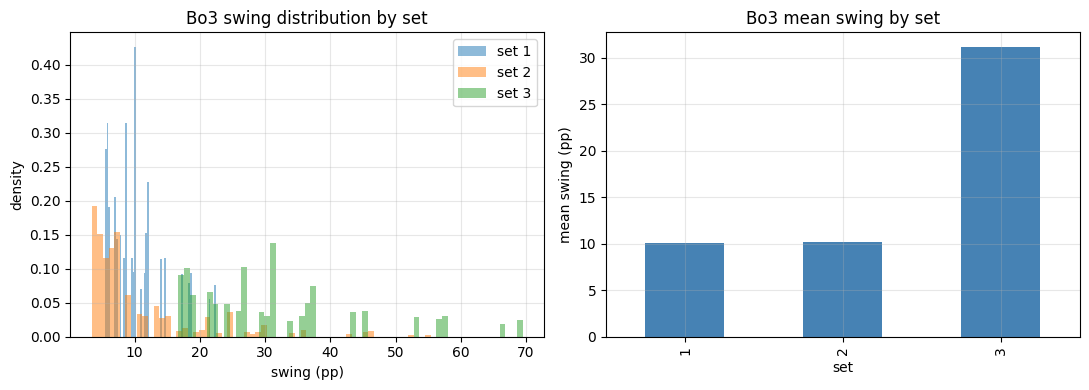

In [6]:
fig, ax = plt.subplots(1, 2)
for s, g in d3.groupby("setno"):
    ax[0].hist(g.swing * 100, bins=60, alpha=.5, density=True, label=f"set {int(s)}")
ax[0].set_xlabel("swing (pp)"); ax[0].set_ylabel("density")
ax[0].set_title("Bo3 swing distribution by set"); ax[0].legend()

t3["mean"].plot(kind="bar", ax=ax[1], color="steelblue")
ax[1].set_ylabel("mean swing (pp)"); ax[1].set_xlabel("set")
ax[1].set_title("Bo3 mean swing by set")
plt.tight_layout(); plt.show()

### Choosing a threshold per set

A fixed threshold keeps very different fractions of each set, because the swing
distribution shifts. The table below shows what share of each set's on-serve games
survive a given `MIN_GAME_SWING`.

In [7]:
def pass_rates(d, thresholds=(0.10, 0.125, 0.15, 0.175, 0.20, 0.25, 0.30)):
    out = {}
    for s, g in d.groupby("setno"):
        out[f"set {int(s)}"] = [(g.swing >= t).mean() * 100 for t in thresholds]
    return pd.DataFrame(out, index=[f"{t*100:.1f}pp" for t in thresholds]).round(0)

print("BO3 - % of on-serve games kept at each threshold")
pass_rates(d3)

BO3 - % of on-serve games kept at each threshold


,set 1,set 2,set 3
10.0pp,45.0,30.0,100.0
12.5pp,18.0,25.0,100.0
15.0pp,11.0,17.0,100.0
17.5pp,9.0,15.0,92.0
20.0pp,4.0,13.0,78.0
25.0pp,0.0,6.0,64.0
30.0pp,0.0,4.0,48.0


Inverting: to keep a **target fraction** of each set, use that set's own quantile.
This is the direct way to pick per-set thresholds.

In [8]:
def thresholds_for(d, keep=(0.50, 0.35, 0.25, 0.15)):
    rows = {}
    for k in keep:
        rows[f"keep {k*100:.0f}%"] = {
            f"set {int(s)}": round(g.swing.quantile(1 - k) * 100, 1)
            for s, g in d.groupby("setno")
        }
    return pd.DataFrame(rows).T

print("BO3 - MIN_GAME_SWING (pp) needed to keep a given share of each set")
thresholds_for(d3)

BO3 - MIN_GAME_SWING (pp) needed to keep a given share of each set


,set 1,set 2,set 3
keep 50%,9.4,6.3,29.1
keep 35%,10.1,8.8,31.2
keep 25%,11.7,11.7,36.3
keep 15%,14.0,17.6,43.3


## Best of 5

In [25]:
%time bo5 = simulate(pA, pB, MATCHES, best_of=5, seed=2)
d5 = bo5[bo5.on_serve & ~bo5.tiebreak]
print(f"{len(bo5):,} game boundaries -> {len(d5):,} on-serve, non-tiebreak")

CPU times: total: 10.8 s
Wall time: 11 s
3,455,288 game boundaries -> 2,071,046 on-serve, non-tiebreak


In [26]:
t5 = swing_table(d5)
print("BO5 - swing in percentage points, on-serve boundaries only")
t5

BO5 - swing in percentage points, on-serve boundaries only


,n,mean,p10,p25,median,p75,p90
set,,,,,,,
1,599909,3.0,1.5,1.8,2.8,3.9,5.8
2,590763,3.1,0.9,1.1,1.9,3.4,7.1
3,592486,3.1,0.3,0.5,0.8,3.9,8.6
4,229011,8.0,2.3,2.8,4.8,8.9,17.6
5,58877,31.0,15.3,17.8,28.4,39.6,58.7


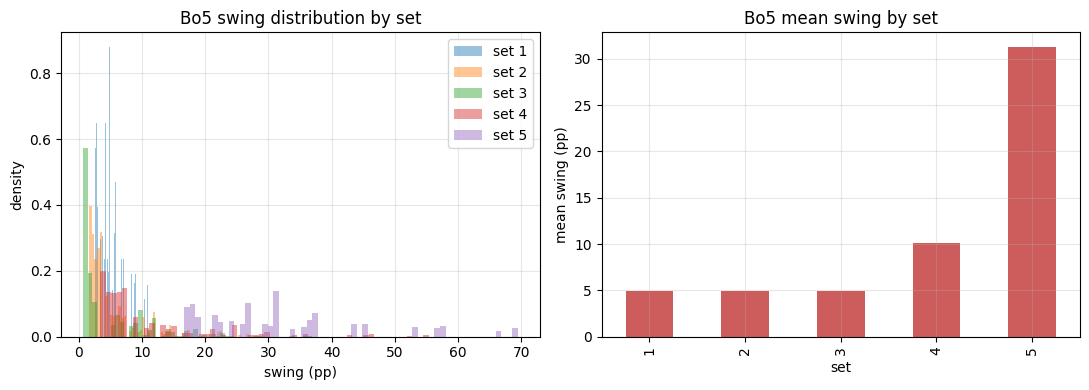

In [11]:
fig, ax = plt.subplots(1, 2)
for s, g in d5.groupby("setno"):
    ax[0].hist(g.swing * 100, bins=60, alpha=.45, density=True, label=f"set {int(s)}")
ax[0].set_xlabel("swing (pp)"); ax[0].set_ylabel("density")
ax[0].set_title("Bo5 swing distribution by set"); ax[0].legend()

t5["mean"].plot(kind="bar", ax=ax[1], color="indianred")
ax[1].set_ylabel("mean swing (pp)"); ax[1].set_xlabel("set")
ax[1].set_title("Bo5 mean swing by set")
plt.tight_layout(); plt.show()

In [12]:
print("BO5 - % of on-serve games kept at each threshold")
display(pass_rates(d5))
print("\nBO5 - MIN_GAME_SWING (pp) needed to keep a given share of each set")
display(thresholds_for(d5))

BO5 - % of on-serve games kept at each threshold


,set 1,set 2,set 3,set 4,set 5
10.0pp,4.0,13.0,19.0,29.0,100.0
12.5pp,0.0,6.0,9.0,24.0,100.0
15.0pp,0.0,4.0,6.0,17.0,100.0
17.5pp,0.0,2.0,5.0,15.0,92.0
20.0pp,0.0,2.0,2.0,13.0,78.0
25.0pp,0.0,1.0,1.0,7.0,64.0
30.0pp,0.0,0.0,0.0,4.0,48.0



BO5 - MIN_GAME_SWING (pp) needed to keep a given share of each set


,set 1,set 2,set 3,set 4,set 5
keep 50%,4.6,3.1,1.5,6.3,29.1
keep 35%,4.9,4.3,5.4,7.6,31.2
keep 25%,5.7,5.7,7.9,11.7,36.3
keep 15%,6.8,8.5,10.1,16.8,43.3


## Side by side

mean swing (pp) by set


,Bo3 mean,Bo5 mean
set,,
1,16.9,11.8
2,16.9,11.9
3,36.2,11.9
4,NaN,16.9
5,NaN,36.2


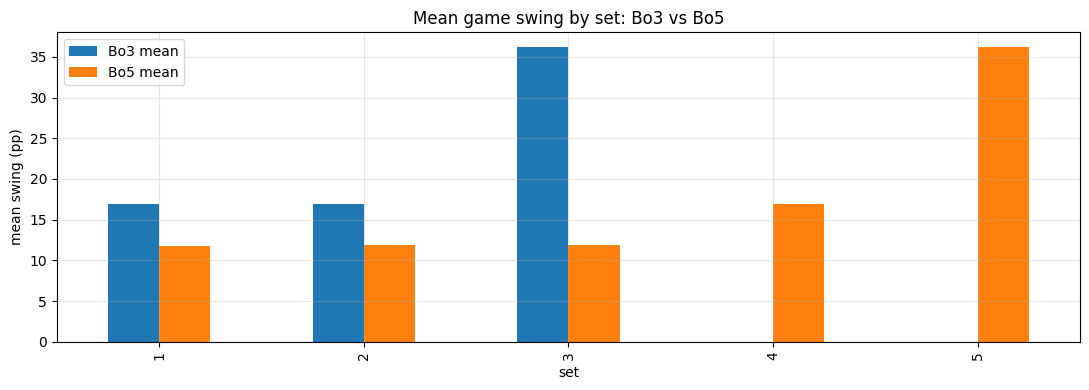

In [13]:
cmp = pd.concat([t3["mean"].rename("Bo3 mean"), t5["mean"].rename("Bo5 mean")], axis=1)
print("mean swing (pp) by set"); display(cmp)

cmp.plot(kind="bar")
plt.ylabel("mean swing (pp)"); plt.xlabel("set")
plt.title("Mean game swing by set: Bo3 vs Bo5")
plt.tight_layout(); plt.show()

## P&L under a per-set threshold policy

Bo3 with `MIN_GAME_SWING` = **0.17 in sets 1-2**, **0.30 in set 3**.

Costs charged per round trip: crossing the spread on both legs, plus Kalshi's taker
fee `ceil(0.07 x C x P x (1-P))` on entry and on exit.

In [14]:
import math

POLICY   = {1: 0.17, 2: 0.17, 3: 0.30}
CONTRACTS      = 20      # fixed size, as in config.py
SPREAD_CENTS   = 1.0     # round-trip cost of buying the ask and selling the bid

def taker(c, p):
    return math.ceil(0.07 * c * p * (1 - p) * 100 - 1e-9) / 100

def apply_policy(d, policy, contracts=CONTRACTS, spread=SPREAD_CENTS):
    x = d[d.on_serve & ~d.tiebreak].copy()
    x = x[x.apply(lambda r: r.swing >= policy.get(int(r.setno), 9.0), axis=1)].copy()
    x["exit"]  = x.price + x.pnl
    x["gross"] = contracts * x.pnl
    x["cost"]  = (contracts * spread / 100.0
                  + x.price.map(lambda p: taker(contracts, p))
                  + x["exit"].map(lambda p: taker(contracts, p)))
    x["net"]   = x.gross - x.cost
    return x

tr = apply_policy(bo3, POLICY)
print(f"policy {POLICY}   {CONTRACTS} contracts   {SPREAD_CENTS:.0f}c spread")
print(f"{len(tr):,} trades over {MATCHES:,} matches  =  {len(tr)/MATCHES:.2f} trades per match")
print()
print(f"  gross P&L per trade   {tr.gross.mean():>+8.4f}")
print(f"  cost  per trade       {tr.cost.mean():>8.4f}")
print(f"  NET   per trade       {tr.net.mean():>+8.4f}   (SE {tr.net.std()/np.sqrt(len(tr)):.4f})")
print()
print(f"  win rate              {(tr.net>0).mean()*100:>7.1f}%")
print(f"  avg win               {tr.net[tr.net>0].mean():>+8.3f}")
print(f"  avg loss              {tr.net[tr.net<=0].mean():>+8.3f}")

policy {1: 0.17, 2: 0.17, 3: 0.3}   20 contracts   1c spread
135,430 trades over 20,000 matches  =  6.77 trades per match

  gross P&L per trade    +0.0016
  cost  per trade         0.8206
  NET   per trade        -0.8190   (SE 0.0062)

  win rate                 18.8%
  avg win                 +3.636
  avg loss                -1.851


PER-MATCH P&L
  mean              -5.546
  median            -3.060
  std dev            8.408
  matches profitable 17.8%   flat 10.9%

  p1             -33.462
  p5             -23.386
  p25             -9.475
  p50             -3.060
  p75             +0.000
  p95             +4.274
  p99             +8.706


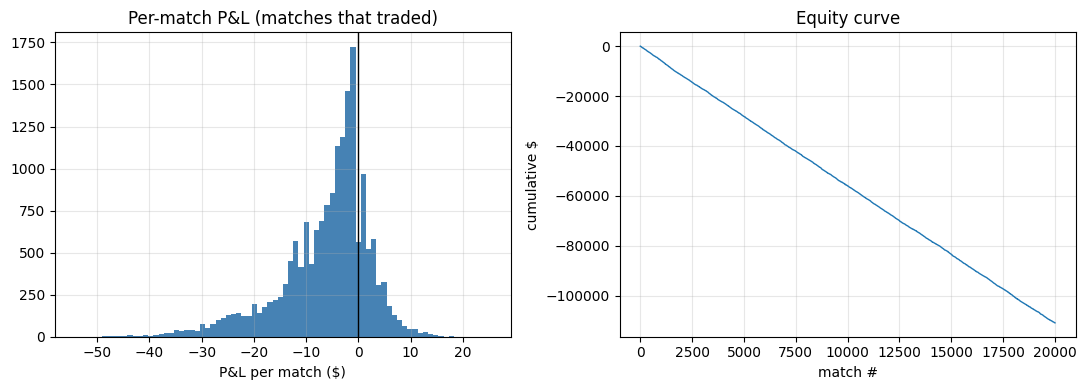

In [15]:
per_match = tr.groupby("match").net.sum().reindex(range(MATCHES), fill_value=0.0)
print("PER-MATCH P&L")
print(f"  mean            {per_match.mean():>+8.3f}")
print(f"  median          {per_match.median():>+8.3f}")
print(f"  std dev         {per_match.std():>8.3f}")
print(f"  matches profitable {(per_match>0).mean()*100:.1f}%   flat {(per_match==0).mean()*100:.1f}%")
print()
for q in (1, 5, 25, 50, 75, 95, 99):
    print(f"  p{q:<3}          {np.percentile(per_match, q):>+8.3f}")

fig, ax = plt.subplots(1, 2)
ax[0].hist(per_match[per_match != 0], bins=80, color="steelblue")
ax[0].axvline(0, color="k", lw=1)
ax[0].set_xlabel("P&L per match ($)"); ax[0].set_title("Per-match P&L (matches that traded)")
ax[1].plot(per_match.cumsum().values, lw=1)
ax[1].set_xlabel("match #"); ax[1].set_ylabel("cumulative $")
ax[1].set_title("Equity curve")
plt.tight_layout(); plt.show()

### How this policy compares to the alternatives

In [16]:
policies = {
    "no filter":              {1: 0.0,  2: 0.0,  3: 0.0},
    "flat 0.149 (current)":   {1: .149, 2: .149, 3: .149},
    "0.17 / 0.17 / 0.30":     {1: .17,  2: .17,  3: .30},
    "0.20 / 0.20 / 0.35":     {1: .20,  2: .20,  3: .35},
    "sets 1-2 off, set3 0.30":{1: 9.0,  2: 9.0,  3: .30},
}
rows = []
for name, pol in policies.items():
    x = apply_policy(bo3, pol)
    pm = x.groupby("match").net.sum().reindex(range(MATCHES), fill_value=0.0)
    rows.append({"policy": name, "trades": len(x),
                 "per match": round(len(x)/MATCHES, 2),
                 "net/trade": round(x.net.mean(), 4) if len(x) else 0.0,
                 "net/match": round(pm.mean(), 4),
                 "total": round(x.net.sum(), 1),
                 "match std": round(pm.std(), 3)})
pd.DataFrame(rows).set_index("policy")

,trades,per match,net/trade,net/match,total,match std
policy,,,,,,
no filter,296815,14.84,-0.7554,-11.2113,-224225.8,10.692
flat 0.149 (current),198943,9.95,-0.8042,-7.9997,-159993.4,9.852
0.17 / 0.17 / 0.30,135430,6.77,-0.8190,-5.5460,-110921.0,8.408
0.20 / 0.20 / 0.35,86295,4.31,-0.8166,-3.5232,-70464.7,6.834
"sets 1-2 off, set3 0.30",41363,2.07,-0.8372,-1.7314,-34628.4,6.007


### The same policy against the real trade logs

The simulation prices every fill at the model's own fair value. The logs are what
actually filled, so this is the check that matters.

In [17]:
import glob, os
LOGS = r"D:\CMU\Kalshi\Tennis Monte Carlo\data\logs"

def load_round_trips():
    tl = []
    for f in glob.glob(os.path.join(LOGS, "trade_log_*.csv")):
        try: d = pd.read_csv(f)
        except Exception: continue
        if d.empty or "event" not in d.columns: continue
        d["ev"] = os.path.basename(f).split("trade_log_")[1].rsplit("_", 1)[0]
        tl.append(d)
    t = pd.concat(tl, ignore_index=True)
    t["ts"] = pd.to_datetime(t.timestamp, errors="coerce")
    t = t.sort_values("ts")
    trips, pend = [], {}
    for _, r in t.iterrows():
        k = (r.ev, str(r.ticker))
        if r.event == "entry":
            pend[k] = r
        elif k in pend:
            en = pend.pop(k)
            if pd.notna(r.pnl) and en.entry_price:
                n = float(en.bet_amount) / float(en.entry_price)
                trips.append({"ev": r.ev, "ts": en.ts, "n": n, "kind": r.event,
                              "net": float(r.pnl) - float(en.fee or 0)})
    return pd.DataFrame(trips)

def load_snaps():
    sn = []
    for f in glob.glob(os.path.join(LOGS, "match_snapshots_*.csv")):
        try: d = pd.read_csv(f)
        except Exception: continue
        if d.empty or "cond_win_game" not in d.columns: continue
        d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
        sn.append(d)
    s = pd.concat(sn, ignore_index=True)
    s["ts"] = pd.to_datetime(s.timestamp, errors="coerce")
    s["swing"] = (pd.to_numeric(s.cond_win_game, errors="coerce")
                  - pd.to_numeric(s.cond_lose_game, errors="coerce")).abs()
    s["setno"] = s.score_str.map(lambda x: len(str(x).split()) if pd.notna(x) else np.nan)
    return s[["ev", "ts", "swing", "setno"]]

rt, sp = load_round_trips(), load_snaps()
hist = pd.merge_asof(rt.sort_values("ts"), sp.sort_values("ts"), on="ts", by="ev",
                     direction="backward", tolerance=pd.Timedelta("180s")).dropna(subset=["swing", "setno"])
hist = hist[(hist.setno <= 3) & (hist.kind == "game_end")]
print(f"{len(hist)} real game-boundary round trips with a known set and swing")

C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  d["ev"] = os.path.basename(f).split("match_snapshots_")[1].rsplit("_", 1)[0]
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of c

157 real game-boundary round trips with a known set and swing


C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  s["ts"] = pd.to_datetime(s.timestamp, errors="coerce")
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  s["swing"] = (pd.to_numeric(s.cond_win_game, errors="coerce")
C:\Users\agran\AppData\Local\Temp\ipykernel_21896\1428458264.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, whi

In [18]:
rows = []
for name, pol in policies.items():
    keep = hist[hist.apply(lambda r: r.swing >= pol.get(int(r.setno), 9.0), axis=1)]
    rows.append({"policy": name, "trades": len(keep),
                 "total P&L": round(keep.net.sum(), 2),
                 "per trade": round(keep.net.mean(), 3) if len(keep) else np.nan,
                 "per contract": round((keep.net/keep.n).mean()*100, 2) if len(keep) else np.nan,
                 "win%": round((keep.net > 0).mean()*100) if len(keep) else np.nan})
print("REAL LOGGED TRADES under each policy")
pd.DataFrame(rows).set_index("policy")

REAL LOGGED TRADES under each policy


,trades,total P&L,per trade,per contract,win%
policy,,,,,
no filter,157,-28.71,-0.183,-1.18,30
flat 0.149 (current),120,-28.62,-0.239,-1.27,28
0.17 / 0.17 / 0.30,78,-28.48,-0.365,-1.30,28
0.20 / 0.20 / 0.35,42,4.40,0.105,1.55,36
"sets 1-2 off, set3 0.30",17,-1.76,-0.104,5.05,47


In [19]:
pol = POLICY
keep = hist[hist.apply(lambda r: r.swing >= pol.get(int(r.setno), 9.0), axis=1)]
print(f"0.17 / 0.17 / 0.30  ->  {len(keep)} of {len(hist)} trades survive")
print()
for s, g in keep.groupby("setno"):
    print(f"  set {int(s)}: n={len(g):>3}  total {g.net.sum():>+7.2f}  per trade {g.net.mean():>+6.3f}")
print(f"\n  TOTAL {keep.net.sum():+.2f}   vs   {hist.net.sum():+.2f} unfiltered")

0.17 / 0.17 / 0.30  ->  78 of 157 trades survive

  set 1: n= 15  total  -11.35  per trade -0.757
  set 2: n= 46  total  -15.36  per trade -0.334
  set 3: n= 17  total   -1.76  per trade -0.104

  TOTAL -28.48   vs   -28.71 unfiltered


### Sensitivity to the serve level

`BASE` sets how often serve is held, which moves the whole swing distribution.
Worth knowing how much the thresholds depend on it.

In [20]:
rows = []
for b in (0.60, 0.62, 0.64, 0.66, 0.68):
    s = simulate(b + GAP, b - GAP, 4000, best_of=3, seed=3)
    s = s[s.on_serve & ~s.tiebreak]
    r = {"BASE": b, "hold%": round(E.game_win_prob(b) * 100, 1)}
    for st, g in s.groupby("setno"):
        r[f"set {int(st)} mean"] = round(g.swing.mean() * 100, 1)
    rows.append(r)
pd.DataFrame(rows).set_index("BASE")

,hold%,set 1 mean,set 2 mean,set 3 mean
BASE,,,,
0.60,72.5,15.7,15.8,33.7
0.62,76.5,16.2,16.3,35.0
0.64,80.3,16.9,16.9,36.2
0.66,83.7,17.6,17.8,37.8
0.68,86.7,18.5,18.6,39.4
